<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/lab%2024/lab_ch24_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 24: Causal ML — Double Machine Learning (Diagnostic Lab)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code**. Your job:
1. Run the code
2. Identify what is wrong (you are told how many bugs, not where)
3. Fix the issue
4. Verify on a known DGP
5. Extend with Causal Forests

**Learning Objectives:**
- Implement manual 2-fold cross-fitting from scratch and debug common mistakes
- Understand why cross-fitting, treatment residualization, and the IV-style formula are each essential
- Estimate the ATE of 401(k) eligibility using the DoubleML package
- Assess robustness with sensitivity analysis
- Fit a Causal Forest (EconML) to estimate individual-level CATEs
- Compare subgroup DML to Causal Forest heterogeneity detection

**Verification checkpoints** are provided so you can confirm you found the right errors.

**Time estimate:** ~60 minutes

---

In [14]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
!pip install -q doubleml econml

from doubleml import DoubleMLData, DoubleMLPLR
from doubleml.datasets import fetch_401K
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from econml.dml import CausalForestDML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Load 401(k) data
data = fetch_401K(return_type='DataFrame')

print(f'Dataset shape: {data.shape}')
print(f'Columns: {list(data.columns)}')
print('Libraries loaded. Ready to diagnose.')

Dataset shape: (9915, 14)
Columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']
Libraries loaded. Ready to diagnose.


---

## Part A: Manual Cross-Fitting — DIAGNOSE

The code below attempts to implement the DML algorithm manually using
2-fold cross-fitting. It has **three deliberate bugs**:

1. **Bug 1 (Data Leakage):** Uses the same data for training AND residual computation — violates cross-fitting
2. **Bug 2 (Missing Residualization):** Only residualizes the outcome $Y$, not the treatment $D$
3. **Bug 3 (Wrong Formula):** Uses `np.mean` of residual products instead of the correct IV-style formula for $\hat{\theta}$

**Your task:** Find all three bugs, explain why each matters, and fix them.

**The correct DML formula:**

$$\hat{\theta} = \frac{\sum_i \tilde{D}_i \tilde{Y}_i}{\sum_i \tilde{D}_i D_i}$$

where $\tilde{Y}_i = Y_i - \hat{\ell}(X_i)$ and $\tilde{D}_i = D_i - \hat{m}(X_i)$ are
the residuals from cross-fitted nuisance models.

In [15]:
# -----------------------------------------------------------
# DIAGNOSE: This code has 3 bugs. Find and fix them all.
# Manual 2-fold cross-fitting DML
# -----------------------------------------------------------

# Generate simulated data with known ATE for verification
np.random.seed(42)
n = 5000
p = 100
TRUE_ATE = 5.0

X_sim = np.random.normal(0, 1, size=(n, p))
propensity = 1 / (1 + np.exp(-(0.5 * X_sim[:, 0] + 0.3 * X_sim[:, 1] + 0.2 * X_sim[:, 2])))
D_sim = np.random.binomial(1, propensity)
Y_sim = (TRUE_ATE * D_sim
         + 2.0 * X_sim[:, 0] + 1.5 * X_sim[:, 1] + 1.0 * X_sim[:, 2]
         + 0.5 * X_sim[:, 3] + 0.3 * X_sim[:, 4]
         + np.random.normal(0, 1, n))


def broken_dml(Y, D, X, random_state=42):
    """
    BROKEN manual DML implementation with 3 bugs.

    Bug 1: Uses same fold for training and prediction (no cross-fitting)
    Bug 2: Only residualizes Y, not D
    Bug 3: Uses np.mean(V_tilde * Y_tilde) instead of sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_tilde = np.zeros(n)  # outcome residuals
    V_tilde = np.zeros(n)  # treatment residuals (but Bug 2 skips this)

    for train_idx, test_idx in kf.split(X):
        # --- Outcome model: Y ~ X ---
        ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

        # BUG 1: Training and predicting on the SAME fold (train_idx)
        # Should train on train_idx, predict on test_idx
        ml_l.fit(X[train_idx], Y[train_idx])
        Y_hat = ml_l.predict(X[train_idx])       # <-- BUG: should be X[test_idx]
        Y_tilde[train_idx] = Y[train_idx] - Y_hat  # <-- BUG: should index test_idx

        # BUG 2: Missing treatment residualization entirely
        # Should fit ml_m on D ~ X and compute D_tilde = D - D_hat
        # Instead, just uses raw D as V_tilde
        V_tilde[train_idx] = D[train_idx]  # <-- BUG: should be D[test_idx] - D_hat[test_idx]

    # BUG 3: Wrong formula — uses np.mean instead of IV-style ratio
    # Correct: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    theta = np.mean(V_tilde * Y_tilde)  # <-- BUG: wrong formula

    return theta


# Run the broken version
broken_ate = broken_dml(Y_sim, D_sim, X_sim)

print('=== BROKEN DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Broken ATE:  {broken_ate:.2f}')
print(f'Bias:        {broken_ate - TRUE_ATE:+.2f}')
print()
print('This estimate is far from the true ATE of 5.0.')
print('Find and fix the 3 bugs to recover the correct estimate.')

=== BROKEN DML Results ===
True ATE:    5.00
Broken ATE:  1.09
Bias:        -3.91

This estimate is far from the true ATE of 5.0.
Find and fix the 3 bugs to recover the correct estimate.


Bug 1: The problem of in-sample prediction. To be specific, ml_l trained on train_idx while also run prediction in it as well instead of in test_idx. Which violate the principle of cross-fitting, to be specific, the residual must be the prediction value of out-of-fold. Using in-sample prediction would lead to overfitting issue to the random forest, which eventually lead to the bias of the overall DML estimation.

Bug 2: The lack of residualization on variable D, in other words the missing treatment residualization. To be specific, the residualization have only done on the variable Y, while similar methods were not used on the variable D. Instead, the original D are used as V_tilde. However, the core of DML is double residualization, which we have to made predicted residuals for both Y and D to X in order to remove the confounding path from X to D. Otherwise there would be selection bias issue.

Bug 3: The problem existed on the calculation formula. To be specific, the formula is wrong, which the np.mean(V_tilde * Y_tilde) is a naive ols and the denominator did not standardized. The correct DML estimation is using the IV style formula, which should be change to np.sum(W_hat*V_hat) / np.sum(W_hat*W_hat). The reason is treatment residual D represents the instrument for it self, while the denominator is the standardization of the treatment variation, which related to the Frisch-Waugh-Lovell theorem.

In [16]:
# -----------------------------------------------------------
# YOUR TASK — Fix the broken DML implementation
# After fixing, verify on the simulated DGP (TRUE_ATE = 5.0)
# -----------------------------------------------------------

def fixed_dml(Y, D, X, random_state=42):
    """
    FIXED manual DML implementation.

    Fix 1: Cross-fit — train on one fold, predict on the other
    Fix 2: Residualize BOTH Y and D
    Fix 3: Use the IV-style formula: theta = sum(V_tilde * Y_tilde) / sum(V_tilde * D)
    """
    from sklearn.base import clone

    n = len(Y)
    kf = KFold(n_splits=2, shuffle=True, random_state=random_state)

    Y_hat = np.zeros(n)
    D_hat = np.zeros(n)

    ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
    ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

    for train_idx, test_idx in kf.split(X):
        ml_l_k = clone(ml_l)
        ml_l_k.fit(X[train_idx], Y[train_idx])
        Y_hat[test_idx] = ml_l_k.predict(X[test_idx])

        ml_m_k = clone(ml_m)
        ml_m_k.fit(X[train_idx], D[train_idx])
        D_hat[test_idx] = ml_m_k.predict(X[test_idx])

    V_hat = Y - Y_hat
    W_hat = D - D_hat

    theta = np.sum(W_hat * V_hat) / np.sum(W_hat * W_hat)

    return theta


# Verify on simulated data
fixed_ate = fixed_dml(Y_sim, D_sim, X_sim)

print('=== FIXED DML Results ===')
print(f'True ATE:    {TRUE_ATE:.2f}')
print(f'Fixed ATE:   {fixed_ate:.2f}')
print(f'Bias:        {fixed_ate - TRUE_ATE:+.2f}')
print()

# VERIFICATION CHECKPOINT
# Your fixed ATE should be within 0.5 of 5.0
# Expected: approximately 4.5 to 5.5
if abs(fixed_ate - TRUE_ATE) < 1.0:
    print('PASS — Fixed ATE is within 1.0 of the true value.')
else:
    print('FAIL — Fixed ATE is still far from 5.0. Check your fixes.')

=== FIXED DML Results ===
True ATE:    5.00
Fixed ATE:   5.15
Bias:        +0.15

PASS — Fixed ATE is within 1.0 of the true value.


---

## Part B: Package-Based DML

Now use the `doubleml` package to estimate the 401(k) ATE properly.
Less scaffolding than the 3916 lab — you should know the API from Part A.

In [17]:
# -----------------------------------------------------------
# YOUR TASK — Estimate the 401(k) ATE with DoubleML
# -----------------------------------------------------------

# Set up DoubleMLData
# y_col: 'net_tfa'
# d_cols: 'e401'
# x_cols: everything else

# YOUR CODE: Create dml_data, define nuisance learners, fit PLR
# Use RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
# for both ml_l and ml_m. Use n_folds=5.

dml_data = DoubleMLData(
    data,
    y_col='net_tfa',
    d_cols='e401',
    x_cols=['age', 'inc', 'fsize', 'educ', 'marr', 'twoearn', 'pira', 'hown']
)

ml_l = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
ml_m = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

dml_plr = DoubleMLPLR(dml_data, ml_l, ml_m, n_folds=5)
dml_plr.fit()

# VERIFICATION CHECKPOINT
# Expected ATE: roughly $7,000-$12,000 (depends on random seed and model)
# Expected: statistically significant (p < 0.05)
print(dml_plr.summary)
print(f'ATE: ${dml_plr.coef[0]:,.0f}')
print(f'95% CI: [{dml_plr.confint().iloc[0,0]:,.0f}, {dml_plr.confint().iloc[0,1]:,.0f}]')

             coef     std err         t         P>|t|        2.5 %  \
e401  8627.698208  1358.34981  6.351603  2.130832e-10  5965.381501   

            97.5 %  
e401  11290.014914  
ATE: $8,628
95% CI: [5,965, 11,290]


In [18]:
# -----------------------------------------------------------
# YOUR TASK — Run sensitivity analysis
# -----------------------------------------------------------

# Use dml_plr.sensitivity_analysis() to assess robustness
# Parameters:
#   cf_y = 0.03  (bound on confounding strength for outcome)
#   cf_d = 0.03  (bound on confounding strength for treatment)
#
# After running:
# 1. Print dml_plr.sensitivity_summary
# 2. Interpret the robustness value
#    - If robustness_value > 1: estimate is very robust
#    - If robustness_value < 1: an omitted variable of moderate
#      strength could flip the sign

dml_plr.sensitivity_analysis()
print(dml_plr.sensitivity_summary)

# VERIFICATION CHECKPOINT
# The robustness value should be positive.
# A value > 0 means the estimate survives some degree of confounding.

================== Sensitivity Analysis ==================

------------------ Scenario          ------------------
Significance Level: level=0.95
Sensitivity parameters: cf_y=0.03; cf_d=0.03, rho=1.0

------------------ Bounds with CI    ------------------
         CI lower  theta lower        theta   theta upper      CI upper
e401  2600.552897  4890.109743  8627.698208  12365.286672  14632.998564

------------------ Robustness Values ------------------
      H_0    RV (%)   RVa (%)
e401  0.0  6.788509  4.968235


Ans: 8628 is the result of the DML estimation, under the consideration of moderate level of unobserved confounding the outcome is still positive, which (cf_y=0.03, cf_d=0.03). Under such a hypothesis, the lower boundary for theta is 4890, which means the positive effect is still remained for 401k participation toward net financial assets, even though there is a missing variable that could both explain the 3% residual variance of treatment and outcome.

The Robustness value rv, which is 6.79%, indicated the only way to reach zero estimation effect is that the unobserved confounding variable should explain both 401k participation qualification and net financial residual variance at least more than 6.79%. While RVa (4.97%) is the requirement for statistically insignificant for the estimation value. The residual ratios of observed control variables like income and educational status are all lower than the threshold, which means that the result unlikely to be freely driven by selection bias. While DML could not completely eliminate all of the counfouders.

---

## Part C: Causal Forests (EXTEND)

DML estimates a single ATE (or subgroup ATEs if you manually split).
**Causal Forests** from the `econml` package estimate individual-level
Conditional Average Treatment Effects (CATEs) — a treatment effect
for every observation.

The `CausalForestDML` combines:
- DML-style cross-fitting for debiasing
- Random Forest splitting to discover heterogeneity
- Honesty: separate samples for splitting and estimation

In [19]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Set up CausalForestDML from EconML
# -----------------------------------------------------------

# Prepare data arrays
y_col = 'net_tfa'
d_col = 'e401'
x_cols = [c for c in data.columns if c not in [y_col, d_col]]

Y = data[y_col].values
D = data[d_col].values.reshape(-1, 1)
X = data[x_cols].values

print(f'Y shape: {Y.shape}')
print(f'D shape: {D.shape}')
print(f'X shape: {X.shape}')
print(f'Covariates: {x_cols}')
print()

# Initialize CausalForestDML
cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,   # Number of causal trees
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5                # Cross-fitting folds
)

print('CausalForestDML configured.')
print('Next: fit the model and extract individual CATEs.')

Y shape: (9915,)
D shape: (9915, 1)
X shape: (9915, 12)
Covariates: ['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'p401', 'pira', 'hown']

CausalForestDML configured.
Next: fit the model and extract individual CATEs.


In [20]:
# -----------------------------------------------------------
# YOUR TASK — Fit Causal Forest and extract CATE predictions
# -----------------------------------------------------------

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import matplotlib.pyplot as plt

# Step 1: Fit the Causal Forest
# Hint: cf.fit(Y, D, X=X)
# This may take 1-3 minutes.
Y = data['net_tfa'].values
D = data['e401'].values
X = data[['age', 'inc', 'fsize', 'educ', 'marr', 'twoearn', 'pira', 'hown']].values

cf = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    model_t=RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42),
    n_estimators=500,
    min_samples_leaf=20,
    max_depth=10,
    random_state=42,
    cv=5
)
cf.fit(Y, D, X=X)

# Step 2: Extract individual CATE predictions
# Hint: cate_predictions = cf.effect(X)
# This returns one treatment effect estimate per observation.
cate_predictions = cf.effect(X)

# Step 3: Get confidence intervals
# Hint: cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)
cate_lower, cate_upper = cf.effect_interval(X, alpha=0.05)

# VERIFICATION CHECKPOINT
print(f'CATE predictions shape: {cate_predictions.shape}')
print(f'Mean CATE:  ${np.mean(cate_predictions):,.0f}')
print(f'Std CATE:   ${np.std(cate_predictions):,.0f}')
print(f'Min CATE:   ${np.min(cate_predictions):,.0f}')
print(f'Max CATE:   ${np.max(cate_predictions):,.0f}')

CATE predictions shape: (9915,)
Mean CATE:  $7,703
Std CATE:   $6,606
Min CATE:   $-10,713
Max CATE:   $44,987


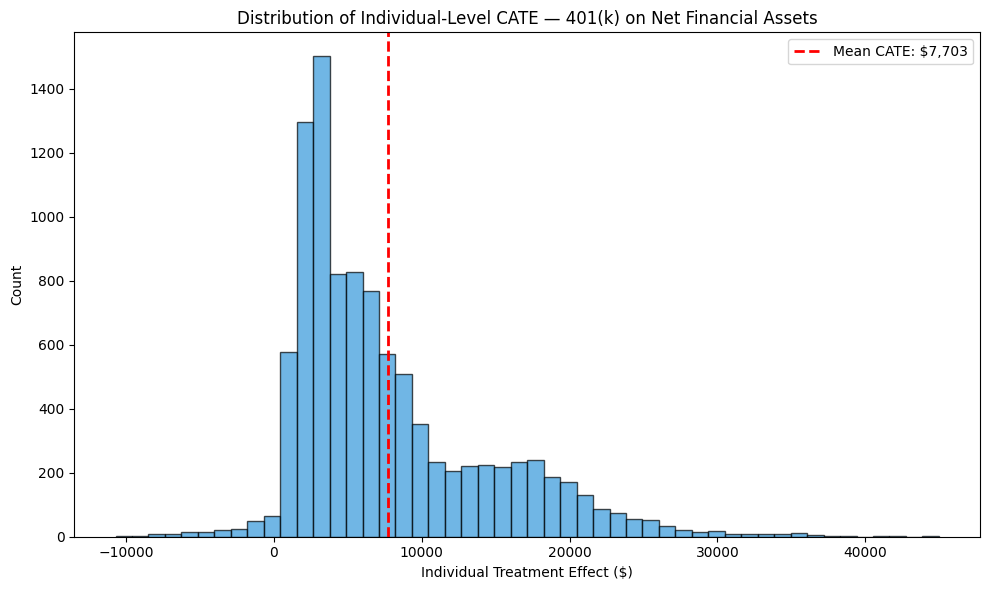

       High CATE (Top 25%)  Low CATE (Bottom 25%)  Full Sample
age                  43.77                  36.95        41.06
inc               66478.87               21330.25     37200.62
educ                 14.25                  12.33        13.21
fsize                 3.08                   2.71         2.87
marr                  0.84                   0.49         0.60
pira                  0.46                   0.14         0.24


In [21]:
# -----------------------------------------------------------
# YOUR TASK — Create CATE histogram and identify high-response subgroup
# -----------------------------------------------------------

# Step 1: Plot a histogram of individual CATE estimates
# Include a vertical line at the mean CATE and the DML ATE for comparison
plt.figure(figsize=(10, 6))
plt.hist(cate_predictions, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
plt.axvline(x=np.mean(cate_predictions), color='red', linestyle='--', linewidth=2,
            label=f'Mean CATE: ${np.mean(cate_predictions):,.0f}')
plt.xlabel('Individual Treatment Effect ($)')
plt.ylabel('Count')
plt.title('Distribution of Individual-Level CATE — 401(k) on Net Financial Assets')
plt.legend()
plt.tight_layout()
plt.show()

# Step 2: Identify the "high-response" subgroup
# Define high-response as individuals with CATE above the 75th percentile
# Compare their characteristics to the rest of the sample

# Hint:
# threshold = np.percentile(cate_predictions, 75)
# high_resp = data[cate_predictions >= threshold]
# low_resp = data[cate_predictions < threshold]
# Compare mean income, age, education, etc.
data['cate'] = cate_predictions
threshold = np.percentile(cate_predictions, 75)
high_resp = data[cate_predictions >= threshold]
low_resp = data[cate_predictions < np.percentile(cate_predictions, 25)]

comparison = pd.DataFrame({
    'High CATE (Top 25%)': high_resp[['age', 'inc', 'educ', 'fsize', 'marr', 'pira']].mean(),
    'Low CATE (Bottom 25%)': low_resp[['age', 'inc', 'educ', 'fsize', 'marr', 'pira']].mean(),
    'Full Sample': data[['age', 'inc', 'educ', 'fsize', 'marr', 'pira']].mean()
})
print(comparison.round(2))

# VERIFICATION CHECKPOINT
# The high-response subgroup should have systematically different
# characteristics (e.g., higher income, different age profile).
# If all subgroup means are identical, something went wrong.

Ans: The High Cate group shows different characteristic comparing to the Low Cate group. To be specific, the income part is the most significant part, which the High Cate group's average income is 66478.87, it is roughly 3.11 times of the Low Cate group. Therefore, we can see income is a crucial participating impact toward 401k. At the same time, the average age for the High Cate group is 43.77, which is 6.82 higher than the Low Cate group of 36.95 years old, the longer compound interest period made the effect of retirement saving account more significant. Within the educational status aspect, High Cate group also has a higher value of 14.25 comparing to 12.33 of the Lower Cate group. Within the marr, High Cate group also has a higher value of 0.84 comparing to 0.49 of the Lower Cate. Such patterns shown the strong financial ability and double income families saving ability. The pira also shown a significant discrepancies between High Cate group and Low Cate group, which High Cate group of 0.46 and Low Cate group with 0.14, this means Low Cate group are relatively negative on retirement saving tools. In conclusion, the treatment effect with the participation of 401k align with the economic theory expectation on high income, high educational status, marriage and elder groups.

                      mean          std  count
inc_quartile                                  
Q1             3320.823242  1924.973548   2481
Q2             3834.653142  2339.667139   2477
Q3             6997.165075  3691.060359   2478
Q4            16658.799702  6075.531796   2479

Within-quartile std vs Between-quartile range:
Between-quartile range: $13,338
Average within-quartile std: $3,508


<Figure size 1000x600 with 0 Axes>

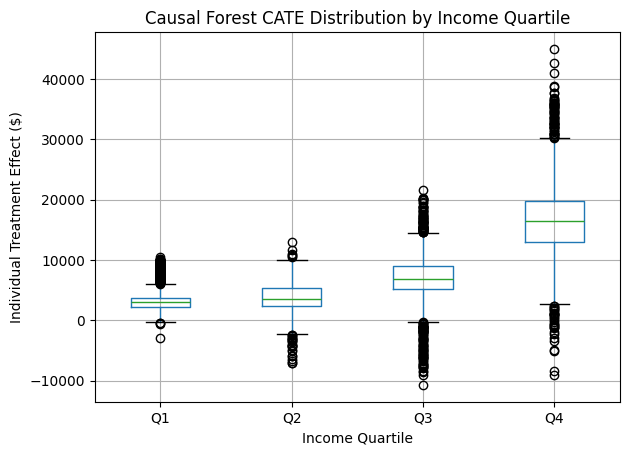


Key question: Does the Causal Forest reveal heterogeneity
WITHIN income quartiles that subgroup DML would miss?


In [22]:
# -----------------------------------------------------------
# EXTEND — Compare subgroup DML to Causal Forest CATE
# -----------------------------------------------------------

# The 3916 lab estimated CATE by income quartile using subgroup DML.
# Here we compare that coarse approach to the Causal Forest's
# continuous CATE predictions.

# Step 1: Compute mean Causal Forest CATE by income quartile
data['inc_quartile'] = pd.qcut(data['inc'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# YOUR CODE: Group cate_predictions by income quartile
# For each quartile, compute mean CATE and std CATE
cate_by_quartile = data.groupby('inc_quartile')['cate'].agg(['mean', 'std', 'count'])
print(cate_by_quartile)

# Step 2: Within each income quartile, how much variation remains?
# If the within-quartile std is large relative to the between-quartile
# difference, then quartile-level DML misses important heterogeneity.
print("\nWithin-quartile std vs Between-quartile range:")
print(f"Between-quartile range: ${cate_by_quartile['mean'].max() - cate_by_quartile['mean'].min():,.0f}")
print(f"Average within-quartile std: ${cate_by_quartile['std'].mean():,.0f}")

# Step 3: Visualize — overlay Causal Forest CATE distribution on
# the quartile-level DML bar chart
# Suggestion: Use a violin plot or box plot of CATE by quartile,
# showing the full distribution within each bin
plt.figure(figsize=(10, 6))
data.boxplot(column='cate', by='inc_quartile')
plt.title('Causal Forest CATE Distribution by Income Quartile')
plt.suptitle('')
plt.xlabel('Income Quartile')
plt.ylabel('Individual Treatment Effect ($)')
plt.tight_layout()
plt.show()

print('\nKey question: Does the Causal Forest reveal heterogeneity')
print('WITHIN income quartiles that subgroup DML would miss?')

---

## Reflection

Answer in 3-5 sentences:

**When would you choose DML for ATE estimation vs. Causal Forests for CATE estimation?**

Consider:
- What is your research question? (average policy effect vs. targeting)
- How much data do you have? (CATE requires more observations per subgroup)
- How interpretable do the results need to be? (ATE is a single number; CATE is a distribution)
- What are the credibility concerns? (ATE with sensitivity analysis vs. CATE with wider CIs)

*Your answer:*

When the research goals is average policy effect estimating, DML would be a better choice since DML offer single ATE estimation, as well as the narrow confidence interval. At the same time, combining with the sensitivity analysis could evaluate the robustness of the result. If the goal is to find out the individual heterogeneity and intervene, the Causal Forest might be better, the reason is Causal Forest does not have to pre identifying the subgroup, it could find multi-dimension interaction effect by data driven. Use this result as an example, the CATE average value gap is 13338 for the four income percentile groups, while each percentile's average standard deviation has a value of 3508, which is what subgroups DML could not captured.

---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken manual DML implementation (3 bugs:
  data leakage in cross-fitting, missing treatment residualization,
  wrong IV-formula for theta)
* Verified the fix recovers the true ATE (=5.0) on a simulated DGP
* Estimated the ATE of 401(k) eligibility on net financial assets
  using DoubleML with Random Forest nuisance learners and 5-fold cross-fitting
* Ran sensitivity analysis to assess robustness to unmeasured confounders
* Fit a CausalForestDML (EconML) to estimate individual-level CATEs
* Compared subgroup DML (quartile-level) to Causal Forest (individual-level)
  heterogeneity detection
* Key finding: [FILL IN — ATE, robustness, which method reveals finer heterogeneity?]

**Please write a README.md entry including:**
1. Project Title: Causal ML — DML and Causal Forests for Policy Evaluation
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-24-causal-ml
git add notebooks/ figures/ README.md
git commit -m "Lab 24: Causal ML — DML & Causal Forests for 401(k) Policy"
git push origin main
```

Submit your GitHub repo link on Canvas.